# 1) Завантаження і підготовка даних

In [ ]:
!pip install mlxtend -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
print("Всі бібліотеки завантажено!")


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

Всі бібліотеки завантажено!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Завантаження датасету

In [ ]:
import urllib.request
import zipfile

url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

print("Завантаження датасету...")
urllib.request.urlretrieve(url, "ml-latest-small.zip")

with zipfile.ZipFile("ml-latest-small.zip", "r") as z: z.extractall(".")

print("Датасет завантажено та розпаковано!")

Завантаження датасету...
Датасет завантажено та розпаковано!


Читання та злиття таблиць

In [ ]:
# основна табличка з оцінками
ratings = pd.read_csv("ml-latest-small/ratings.csv")

# назви і жанри фільмів
movies = pd.read_csv("ml-latest-small/movies.csv")

# об'єднуємо по movieId. лишаємо тільки ті рядки де movieId є в обох таблицях
df = ratings.merge(movies, on="movieId", how="inner")

print("-" * 55)
print("Розміри таблиць")
print("-" * 55)
print(f"ratings.csv:{ratings.shape[0]:,} рядків, {ratings.shape[1]} колонок")
print(f"movies.csv:{movies.shape[0]:,} рядків, {movies.shape[1]} колонок")
print(f"Після злиття: {df.shape[0]:,} рядків, {df.shape[1]} колонок")
print(f"Унікальних користувачів: {df['userId'].nunique():,}")
print(f"Унікальних фільмів: {df['movieId'].nunique():,}")
print(f"Діапазон оцінок: {df['rating'].min()} – {df['rating'].max()}")
print("-" * 55)

print("\nПерші 5 рядків об'єднаної таблиці:")
df.head()


-------------------------------------------------------
Розміри таблиць
-------------------------------------------------------
ratings.csv:100,836 рядків, 4 колонок
movies.csv:9,742 рядків, 3 колонок
Після злиття: 100,836 рядків, 6 колонок
Унікальних користувачів: 610
Унікальних фільмів: 9,724
Діапазон оцінок: 0.5 – 5.0
-------------------------------------------------------

Перші 5 рядків об'єднаної таблиці:


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Фільтрація оцінок

Рядків до фільтрації: 100,836
Рядків після фільтрації: 48,580
Частка позитивних оцінок: 48.2%
Активних користувачів після фільтрації: 609
Фільмів з позитивними оцінками: 6297


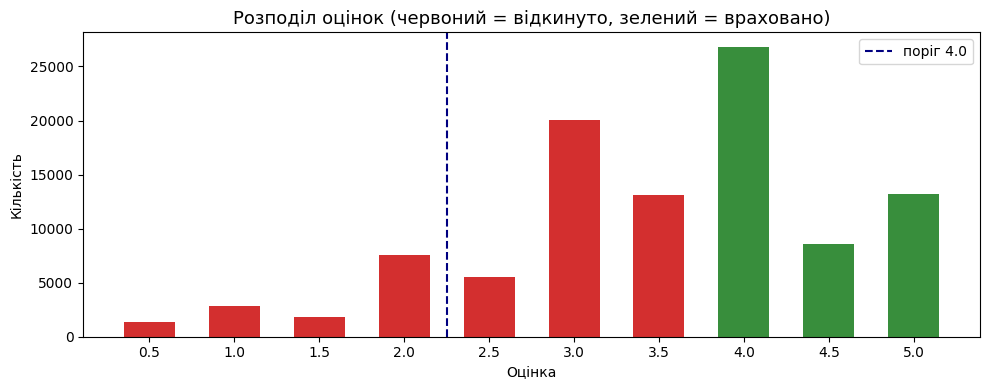

In [ ]:
# відбираємо лише rating >= 4.0
liked = df[df["rating"] >= 4.0].copy()

print(f"Рядків до фільтрації: {len(df):,}")
print(f"Рядків після фільтрації: {len(liked):,}")
print(f"Частка позитивних оцінок: {len(liked)/len(df)*100:.1f}%")
print(f"Активних користувачів після фільтрації: {liked['userId'].nunique()}")
print(f"Фільмів з позитивними оцінками: {liked['title'].nunique()}")

# розподіл оцінок
fig, ax = plt.subplots(figsize=(10, 4))
rating_counts = df["rating"].value_counts().sort_index()
colors = ["#d32f2f" if r < 4.0 else "#388e3c" for r in rating_counts.index]
ax.bar(rating_counts.index.astype(str), rating_counts.values, color=colors, width=0.6)
ax.axvline(x=3.5, color="navy", linestyle="--", linewidth=1.5, label="поріг 4.0")
ax.set_title("Розподіл оцінок (червоний = відкинуто, зелений = враховано)", fontsize=13)
ax.set_xlabel("Оцінка")
ax.set_ylabel("Кількість")
ax.legend()
plt.tight_layout()
plt.show()


# 2) Перетворення даних у транзакційний формат

 Побудова бінарної матриці

In [ ]:
# рядки = користувачі, стовпці = фільми
user_movie_matrix = liked.pivot_table(index="userId", columns="title", values="rating",aggfunc=lambda x: 1, fill_value=0).astype(bool)

print(f"Розмір матриці: {user_movie_matrix.shape}")
print(f"- {user_movie_matrix.shape[0]} користувачів (рядки)")
print(f"- {user_movie_matrix.shape[1]} фільмів (стовпці)")
print(f"Щільність матриці: {user_movie_matrix.values.mean()*100:.2f}%")
print(f"(частка комірок зі значенням True)")

print("\nФрагмент матриці:")
user_movie_matrix.iloc[:12, :6]


Розмір матриці: (609, 6297)
- 609 користувачів (рядки)
- 6297 фільмів (стовпці)
Щільність матриці: 1.27%
(частка комірок зі значенням True)

Фрагмент матриці:


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009)
userId,,,,,,
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False
8,False,False,False,False,False,False
9,False,False,False,False,False,False


# 3) Пошук частих наборів фільмів

Відбір популярних фільмів

In [ ]:
# рахуємо скільки разів кожен фільм потрапив у сподобалось
movie_popularity = user_movie_matrix.sum().sort_values(ascending=False)

# відбираємо фільми з >= 50 позитивних оцінок
MIN_RATINGS = 50
popular_movies = movie_popularity[movie_popularity >= MIN_RATINGS].index

print(f"Всього фільмів у матриці:{len(movie_popularity)}")
print(f"Фільмів з >= {MIN_RATINGS} оцінок:{len(popular_movies)}")

# обрізаємо матрицю до популярних фільмів
matrix_filtered = user_movie_matrix[popular_movies]

# видаляємо користувачів у яких після фільтрації 0 або 1 фільм (вони не можуть утворити правило x -> y)
user_counts = matrix_filtered.sum(axis=1)
matrix_filtered = matrix_filtered[user_counts >= 2]

print(f"\nФінальна матриця для аналізу:")
print(f" {matrix_filtered.shape[0]} користувачів × {matrix_filtered.shape[1]} фільмів")


print("\nТоп-15 найпопулярніших фільмів:")
for i, (title, count) in enumerate(movie_popularity.head(15).items(), 1):
    print(f" {i:2}.{title[:55]:<55} [{count} оцінок]")


Всього фільмів у матриці:6297
Фільмів з >= 50 оцінок:167

Фінальна матриця для аналізу:
 585 користувачів × 167 фільмів

Топ-15 найпопулярніших фільмів:
  1.Shawshank Redemption, The (1994)                        [274 оцінок]
  2.Forrest Gump (1994)                                     [249 оцінок]
  3.Pulp Fiction (1994)                                     [244 оцінок]
  4.Silence of the Lambs, The (1991)                        [225 оцінок]
  5.Matrix, The (1999)                                      [222 оцінок]
  6.Star Wars: Episode IV - A New Hope (1977)               [201 оцінок]
  7.Fight Club (1999)                                       [179 оцінок]
  8.Schindler's List (1993)                                 [175 оцінок]
  9.Star Wars: Episode V - The Empire Strikes Back (1980)   [168 оцінок]
 10.Braveheart (1995)                                       [166 оцінок]
 11.Raiders of the Lost Ark (Indiana Jones and the Raiders  [163 оцінок]
 12.Usual Suspects, The (1995)              

Apriori при різних порогах

In [ ]:
thresholds = [0.05, 0.09, 0.15, 0.2, 0.3]
results_summary = []

print(f"{"min_support":>12} | {"Наборів":>9} | {"Час (с)":>8} | Найбільший")
print("-" * 65)

import time
for thresh in thresholds:
    t0 = time.time()
    fi = apriori(matrix_filtered, min_support=thresh, use_colnames=True, max_len=4)
    elapsed = time.time() - t0
    max_size = fi["itemsets"].apply(len).max() if len(fi) > 0 else 0
    results_summary.append({"min_support": thresh, "count": len(fi), "time": round(elapsed, 2), "max_len": max_size })
    print(f"{thresh:>12.2f} | {len(fi):>9,} | {elapsed:>8.2f} | {max_size}-елементних")


print(" min_support = 0.09")
MIN_SUPPORT = 0.09
frequent_items = apriori(matrix_filtered, min_support=MIN_SUPPORT, use_colnames=True, max_len=5)

frequent_items["length"] = frequent_items["itemsets"].apply(len)
print(f"Знайдено {len(frequent_items):,} частих наборів")
print(f"Розподіл за розміром:")
print(frequent_items["length"].value_counts().sort_index())


 min_support |   Наборів |  Час (с) | Найбільший
-----------------------------------------------------------------
        0.05 |    30,633 |     8.28 | 4-елементних
        0.09 |     1,690 |     0.30 | 4-елементних
        0.15 |       150 |     0.02 | 3-елементних
        0.20 |        50 |     0.01 | 2-елементних
        0.30 |         7 |     0.00 | 1-елементних
 min_support = 0.09
Знайдено 1,694 частих наборів
Розподіл за розміром:
length
1    155
2    683
3    660
4    192
5      4
Name: count, dtype: int64


 Графік кількість наборів vs min_support

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

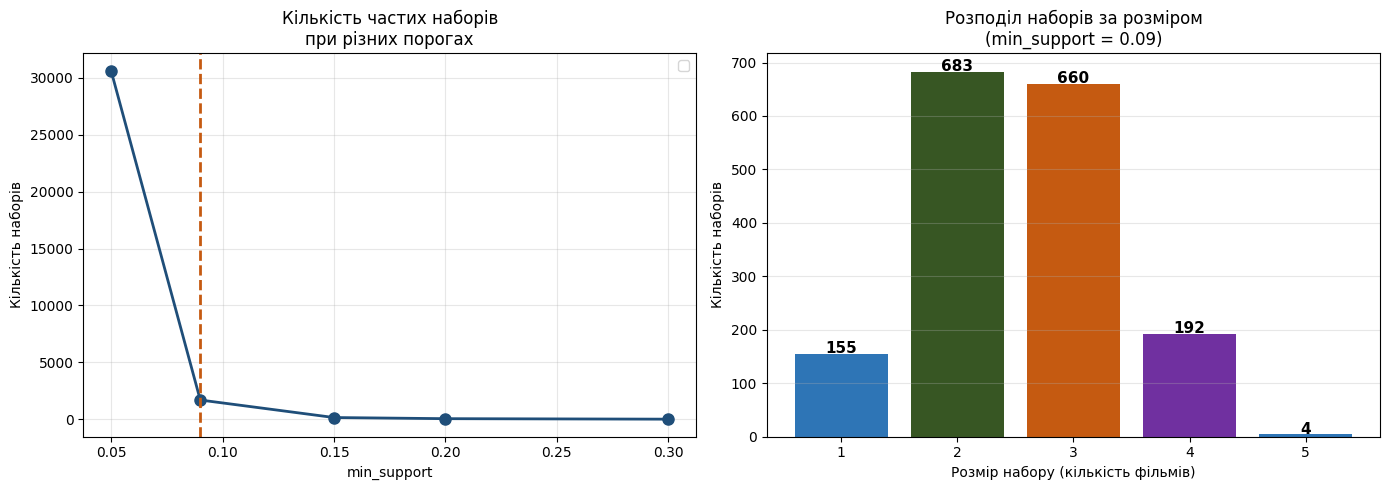

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# лівий кількість наборів при різних порогах
df_res = pd.DataFrame(results_summary)
axes[0].plot(df_res["min_support"], df_res["count"], "o-", color="#1F4E79", linewidth=2, markersize=8)
axes[0].axvline(x=0.09, color="#C55A11", linestyle="--", linewidth=2)
axes[0].set_title("Кількість частих наборів\nпри різних порогах", fontsize=12)
axes[0].set_xlabel("min_support")
axes[0].set_ylabel("Кількість наборів")
axes[0].legend()
axes[0].grid(alpha=0.3)

# правий розподіл наборів за розміром
size_dist = frequent_items["length"].value_counts().sort_index()
axes[1].bar(size_dist.index.astype(str), size_dist.values, color=["#2E75B6", "#375623", "#C55A11", "#7030A0"][:len(size_dist)])
axes[1].set_title(f"Розподіл наборів за розміром\n(min_support = {MIN_SUPPORT})", fontsize=12)
axes[1].set_xlabel("Розмір набору (кількість фільмів)")
axes[1].set_ylabel("Кількість наборів")
for i, v in enumerate(size_dist.values): axes[1].text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


Топ-10 наборів за support

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ТОП-10 частих наборів (за підтримкою):
------------------------------------------------------------------------------------------
 1. Support = 0.468. Shawshank Redemption, The
 2. Support = 0.426. Forrest Gump
 3. Support = 0.417. Pulp Fiction
 4. Support = 0.385. Silence of the Lambs, The
 5. Support = 0.379. Matrix, The
 6. Support = 0.344. Star Wars: Episode IV - A New Hope
 7. Support = 0.306. Fight Club
 8. Support = 0.297. Schindler's List
 9. Support = 0.287. Shawshank Redemption, The + Forrest Gump
10. Support = 0.287. Star Wars: Episode V - The Empire Strikes Back
------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

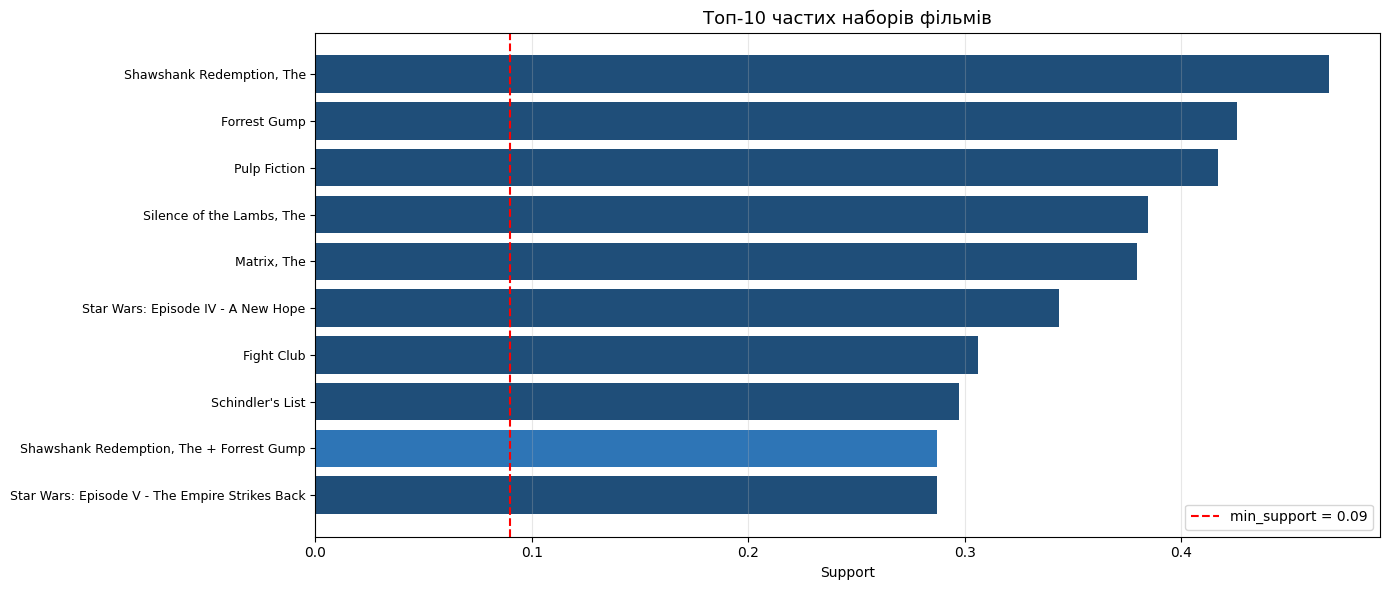

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# топ-10 частих наборів за support
top10 = (frequent_items.sort_values("support", ascending=False).head(10).reset_index(drop=True))

print("ТОП-10 частих наборів (за підтримкою):")
print("-" * 90)

for i, row in top10.iterrows():
    films = [f.split("(")[0].strip() for f in row["itemsets"]]
    print(f"{i+1:2}. Support = {row['support']:.3f}. {' + '.join(films)}")

print("-" * 90)


labels = [" + ".join([f.split("(")[0].strip() for f in row["itemsets"]])
    for _, row in top10.iterrows()]

colors = []
for _, row in top10.iterrows():
    itemset_len = len(row["itemsets"])
    if itemset_len == 1:
        colors.append("#1F4E79")
    elif itemset_len == 2:
        colors.append("#2E75B6")
    else:
        colors.append("#375623")

# графік
fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(range(len(labels)), top10["support"].values, color=colors)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel("Support")
ax.set_title("Топ-10 частих наборів фільмів", fontsize=13)

ax.axvline(x=MIN_SUPPORT, color="red", linestyle="--", label=f"min_support = {MIN_SUPPORT}")

ax.legend()
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# 4) Побудова асоціативних правил

Генерація правил

In [ ]:
# генеруємо правила з мінімальною впевненістю
MIN_CONFIDENCE = 0.50
rules = association_rules(frequent_items, metric="confidence",min_threshold=MIN_CONFIDENCE)

# додаємо зручну колонку - розмір antecedents
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)

print(f"Знайдено {len(rules):,} асоціативних правил")
print(f"при min_support = {MIN_SUPPORT}, min_confidence = {MIN_CONFIDENCE}")
print("Розподіл за довжиною лівої частини (antecedent):")
print(rules["antecedent_len"].value_counts().sort_index())

# базова статистика метрик
print("\nСтатистика метрик:")
print(rules[["support","confidence","lift"]].describe().round(3))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Знайдено 4,063 асоціативних правил
при min_support = 0.09, min_confidence = 0.5
Розподіл за довжиною лівої частини (antecedent):
antecedent_len
1     818
2    2418
3     807
4      20
Name: count, dtype: int64

Статистика метрик:
        support  confidence      lift
count  4063.000    4063.000  4063.000
mean      0.107       0.688     2.522
std       0.020       0.127     0.884
min       0.091       0.500     1.073
25%       0.094       0.578     1.874
50%       0.101       0.675     2.304
75%       0.111       0.781     3.028
max       0.287       1.000     7.124


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Топ-10 за lift




In [ ]:
top_lift = (rules.sort_values("lift", ascending=False).head(10).reset_index(drop=True))

print("ТОП-10 правил за lift:")
print("-" * 100)
for i, row in top_lift.iterrows():
    ant = [f.split("(")[0].strip()[:30] for f in list(row["antecedents"])]
    cons = [f.split("(")[0].strip()[:30] for f in list(row["consequents"])]
    print(f"{i+1:2}. {'{' + ', '.join(ant) + '}':40} → {', '.join(cons)}")
    print(f"support={row['support']:.3f} | confidence={row['confidence']:.3f}| lift={row['lift']:.3f}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ТОП-10 правил за lift:
----------------------------------------------------------------------------------------------------
 1. {Lord of the Rings: The Return , Star Wars: Episode VI - Return} → Star Wars: Episode V - The Emp, Lord of the Rings: The Two Tow
support=0.091 | confidence=0.828| lift=7.124
 2. {Star Wars: Episode V - The Emp, Lord of the Rings: The Two Tow} → Lord of the Rings: The Return , Star Wars: Episode VI - Return
support=0.091 | confidence=0.779| lift=7.124
 3. {Lord of the Rings: The Return , Star Wars: Episode V - The Emp} → Lord of the Rings: The Two Tow, Star Wars: Episode VI - Return
support=0.091 | confidence=0.688| lift=7.064
 4. {Lord of the Rings: The Two Tow, Star Wars: Episode VI - Return} → Lord of the Rings: The Return , Star Wars: Episode V - The Emp
support=0.091 | confidence=0.930| lift=7.064
 5. {Star Wars: Episode V - The Emp, Lord of the Rings: The Two Tow} → Lord of the Rings: The Fellows, Lord of the Rings: The Return , Star Wars: Episode IV - A

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Детальна інтерпретація

In [ ]:
def interpret_rule(rule_row, all_users):
    ant = list(rule_row["antecedents"])
    cons = list(rule_row["consequents"])
    n_users = len(all_users)

    print(f"ПРАВИЛО: {{{', '.join(a.split('(')[0].strip() for a in ant)}}}")
    print(f"- {{{', '.join(c.split('(')[0].strip() for c in cons)}}}")
    print(f"-" * 60)
    print(f"Support = {rule_row['support']:.3f}",
          f"- ~{int(rule_row['support']*n_users)} з {n_users} користувачів")
    print(f"Confidence = {rule_row['confidence']:.3f}",
          f"- {rule_row['confidence']*100:.0f}% людей, що люблять X, люблять і Y")
    print(f"Lift = {rule_row['lift']:.3f}")
    if rule_row["lift"] > 1:
        print(f"- Правило значуще! Y з'{chr(39)}являється у {rule_row['lift']:.1f}x частіше")

# виводимо топ-3 правила
for _, row in top_lift.head(3).iterrows():
    interpret_rule(row, matrix_filtered.index)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ПРАВИЛО: {Lord of the Rings: The Return of the King, The, Star Wars: Episode VI - Return of the Jedi}
- {Star Wars: Episode V - The Empire Strikes Back, Lord of the Rings: The Two Towers, The}
------------------------------------------------------------
Support = 0.091 - ~53 з 585 користувачів
Confidence = 0.828 - 83% людей, що люблять X, люблять і Y
Lift = 7.124
- Правило значуще! Y з''являється у 7.1x частіше
ПРАВИЛО: {Star Wars: Episode V - The Empire Strikes Back, Lord of the Rings: The Two Towers, The}
- {Lord of the Rings: The Return of the King, The, Star Wars: Episode VI - Return of the Jedi}
------------------------------------------------------------
Support = 0.091 - ~53 з 585 користувачів
Confidence = 0.779 - 78% людей, що люблять X, люблять і Y
Lift = 7.124
- Правило значуще! Y з''являється у 7.1x частіше
ПРАВИЛО: {Lord of the Rings: The Return of the King, The, Star Wars: Episode V - The Empire Strikes Back}
- {Lord of the Rings: The Two Towers, The, Star Wars: Episode VI

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 5) Аналіз та висновки

Support vs Confidence.  Кожна точка - одне правило. Колір показує значення lift. Хороші правила знаходяться у правому верхньому куті (висока підтримка і висока впевненість).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

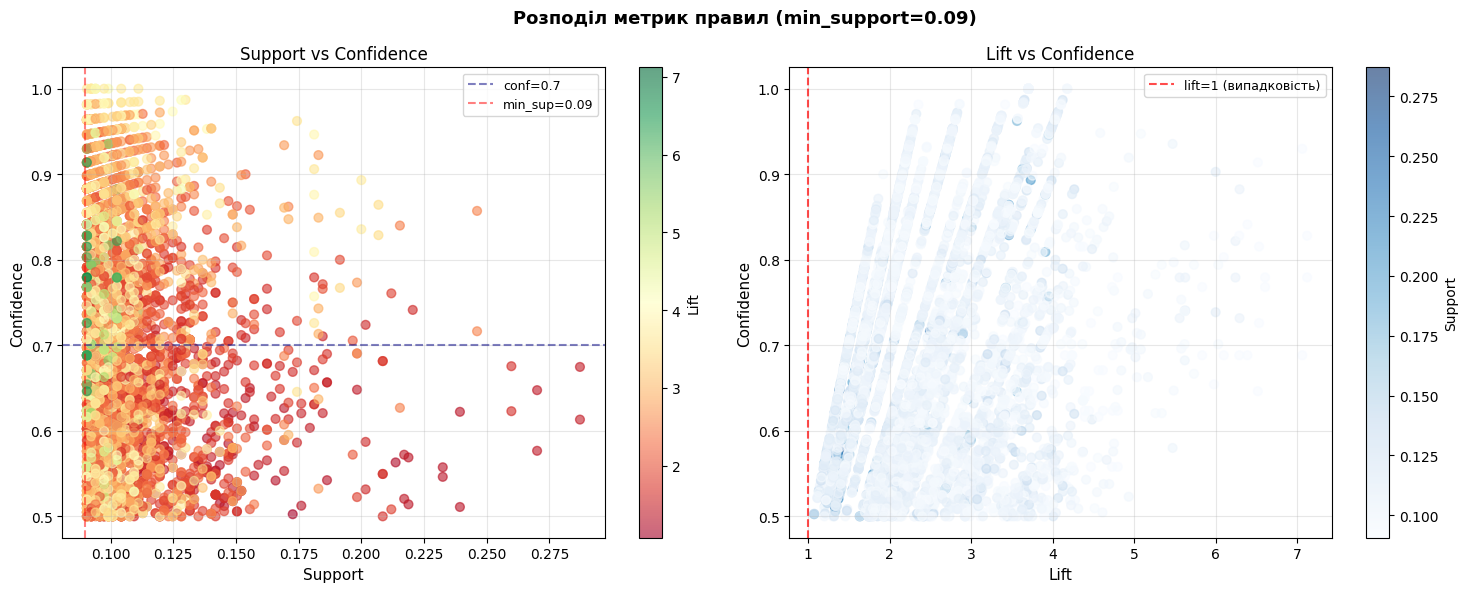

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# лівий support vs confidence
sc = axes[0].scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="RdYlGn", alpha=0.6, s=40 )
plt.colorbar(sc, ax=axes[0], label="Lift")
axes[0].set_xlabel("Support", fontsize=11)
axes[0].set_ylabel("Confidence", fontsize=11)
axes[0].set_title("Support vs Confidence", fontsize=12)
axes[0].axhline(y=0.7, color="navy", linestyle="--", alpha=0.5, label="conf=0.7")
axes[0].axvline(x=MIN_SUPPORT, color="red", linestyle="--", alpha=0.5, label=f"min_sup={MIN_SUPPORT}")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# правий lift vs confidence
sc2 = axes[1].scatter(rules["lift"], rules["confidence"], c=rules["support"], cmap="Blues", alpha=0.6, s=40)
plt.colorbar(sc2, ax=axes[1], label="Support")
axes[1].axvline(x=1.0, color="red", linestyle="--", alpha=0.7, label="lift=1 (випадковість)")
axes[1].set_xlabel("Lift", fontsize=11)
axes[1].set_ylabel("Confidence", fontsize=11)
axes[1].set_title("Lift vs Confidence", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Розподіл метрик правил (min_support={MIN_SUPPORT})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Більшість правил мають support у невеликому діапазоні (через розрідженість даних). Найкращі правила знаходяться у зоні: високий confidence, lift значно більше 1

Асоціативні правила можуть бути використані для побудови рекомендаційної системи:

- якщо користувач вподобав фільм X, система шукає правило X -> Y
- фільм Y рекомендується користувачу
- правила з високим confidence означають високу ймовірність рекомендації
- правила з lift > 1 означають що рекомендація не є випадково

Вплив параметрів min_support та min_confidence

In [ ]:
# таблиця впливу параметрів
data = {"Параметр": ["min_support", "min_confidence"],
        "Збільшення значення": ["менше наборів, швидше, вища якість", "менше правил, але точніші" ],
        "Зменшення значення": ["більше наборів, більше шуму","більше правил, але слабші"]}
df_params = pd.DataFrame(data)

print("Таблиця впливу параметрів:")
display(df_params)

Таблиця впливу параметрів:


,Параметр,Збільшення значення,Зменшення значення
0,min_support,"менше наборів, швидше, вища якість","більше наборів, більше шуму"
1,min_confidence,"менше правил, але точніші","більше правил, але слабші"


Асоціативні правила дозволяють виявляти закономірності у вподобаннях користувачів та можуть бути використані для побудови рекомендаційних систем. Параметри min_support і min_confidence суттєво впливають на кількість і якість правил тому їх необхідно підбирати з урахуванням компромісу між точністю та повнотою.